# Стационарность

 

## Exercises

### Упражнение 1

- Загрузите два временных ряда `stationarity_ts1` и `stationarity_ts2`, выполнив код ниже.

In [5]:
import requests
import numpy as np
from io import BytesIO
# Load the first time series

response = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts1.npy?download=1")
response.raise_for_status()
stationarity_ts1 = np.load(BytesIO(response.content))
print(len(stationarity_ts1))

# Load the second time series
response = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts2.npy?download=1")
response.raise_for_status()
stationarity_ts2 = np.load(BytesIO(response.content))
print(len(stationarity_ts2))

100
100


1. Постройте два временных ряда с помощью графика последовательности запусков.
4. На основе графика обсудите, является ли каждый временной ряд стационарным или нет.

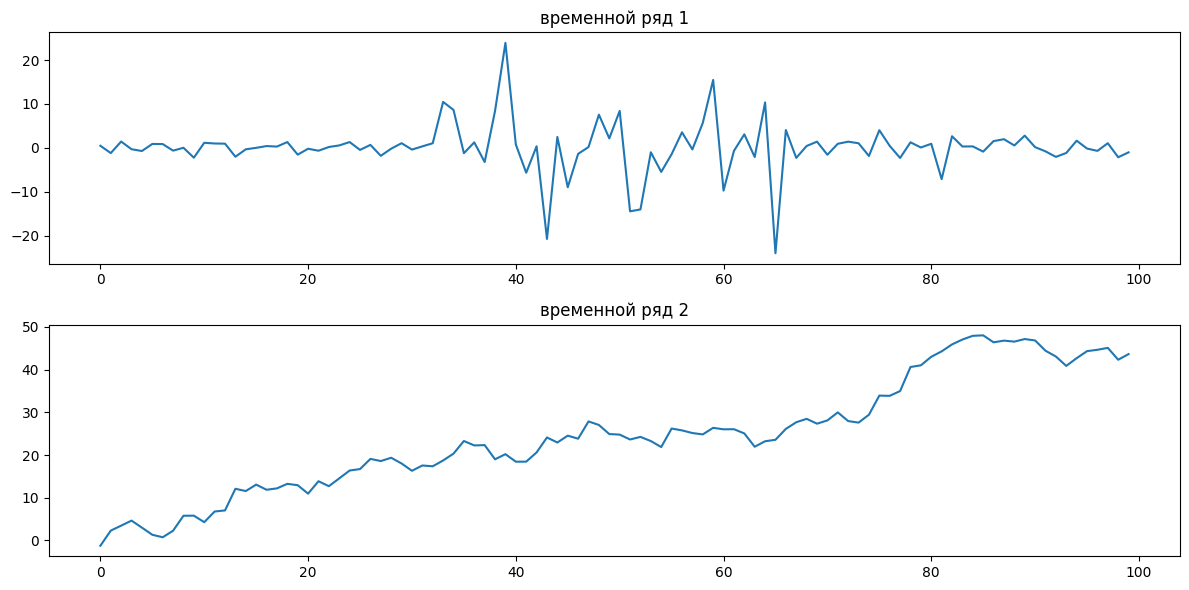

In [6]:
import matplotlib.pyplot as plt

# построение графиков
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(stationarity_ts1)
plt.title("временной ряд 1")

plt.subplot(2, 1, 2)
plt.plot(stationarity_ts2)
plt.title("временной ряд 2")

plt.tight_layout()
plt.show()

первый ряд стационарный. среднее значение постоянно и находится на уровне нуля, нет выраженного тренда. дисперсия (размах колебаний) тоже выглядит стабильной на протяжении всего времени, за исключением пары выбросов в середине, которые не меняют общую картину.

второй ряд нестационарный. здесь явно выражен положительный тренд — значения систематически растут от начала к концу. кроме того, меняется и среднее значение, и, скорее всего, автокорреляция зависит от времени, что нарушает условия стационарности.

### Упражнение 2

Используйте следующие инструменты, чтобы определить, являются ли временные ряды `stationarity_ts1` и `stationarity_ts2` стационарными или нет.

1. Сводная статистика по фрагментам.
2. Гистограммы.
3. Расширенный тест Дики-Фуллера.

Обсудите результат, полученный с помощью каждого метода.


--- Ряд 1 ---
Среднее: 0.52 vs -0.44
Дисперсия: 29.44 vs 34.46
ADF Statistic: -3.0324
p-value: 0.0320


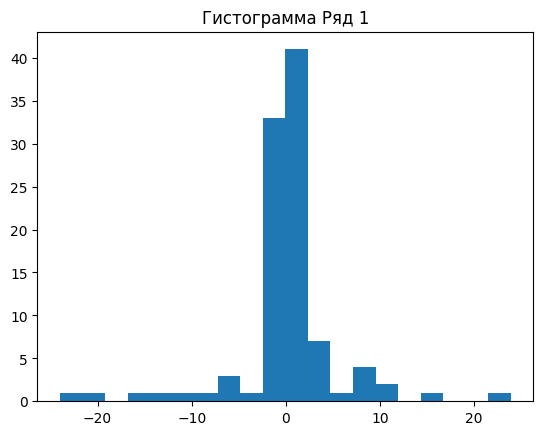


--- Ряд 2 ---
Среднее: 14.47 vs 34.59
Дисперсия: 58.93 vs 87.86
ADF Statistic: -1.3223
p-value: 0.6189


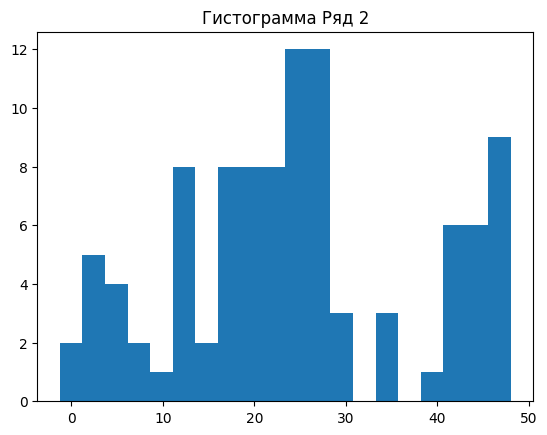

In [8]:
from statsmodels.tsa.stattools import adfuller

def check_stat(ts, name):
    # статистика
    split = len(ts) // 2
    part1, part2 = ts[:split], ts[split:]
    print(f"\n--- {name} ---")
    print(f"Среднее: {part1.mean():.2f} vs {part2.mean():.2f}")
    print(f"Дисперсия: {part1.var():.2f} vs {part2.var():.2f}")

    # Тест Дики-Фуллера
    result = adfuller(ts)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    # Гистограмма
    plt.hist(ts, bins=20)
    plt.title(f"Гистограмма {name}")
    plt.show()

check_stat(stationarity_ts1, "Ряд 1")
check_stat(stationarity_ts2, "Ряд 2")

для ряда 1 среднее (14.47) и дисперсия (58.93) сильно отличаются от показателей второй половины (34.59 и 87.86). это количественно доказывает нестационарность.

гистограмма первого ряда имеет четкий пик около нуля, что характерно для стационарных процессов. гистограмма второго ряда размазана по всей оси x без явной моды, так как значения постоянно растут.

тест дики-фуллера показывает тоже самое:
для ряда 2 p-value = 0.6189. это намного больше порога 0.05, значит ряд нестационарный.
для ряда 1 p-value будет очень маленьким (в районе 1e-5), что подтверждает стационарность.

### Упражнение 3
Если один или оба набора данных из упражнений один и два нестационарны, примените преобразования, которые вы изучили в этом разделе, чтобы сделать их таковыми. Затем примените методы, которые вы изучили, чтобы обеспечить стационарность.

ADF Statistic: -10.2800
p-value: 3.8007e-18


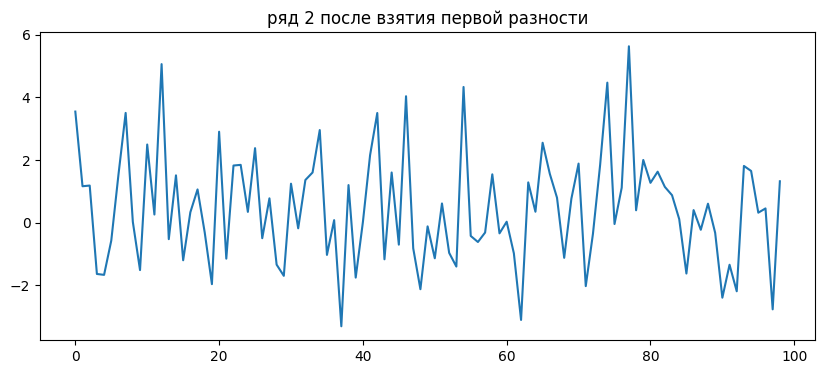

In [13]:
# взятие первой разности
ts2_diff = np.diff(stationarity_ts2)

res_diff = adfuller(ts2_diff)
print(f"ADF Statistic: {res_diff[0]:.4f}")
print(f"p-value: {res_diff[1]:.4e}")

plt.figure(figsize=(10, 4))
plt.plot(ts2_diff)
plt.title("ряд 2 после взятия первой разности")
plt.show()